# Exercise 3

In this exercise, you will analyse a dataset obtained from the London transport system (TfL). The data is in a filled called `tfl_readership.csv` (comma-separated-values format).  As in Exercise 2, we will load and view the data using  `pandas`. 

In [69]:
# If you are running this on Google Colab, uncomment and run the following lines; otherwise ignore this cell
# from google.colab import drive
# drive.mount('/content/drive')

In [70]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [71]:
# Load data
df_tfl = pd.read_csv('tfl_ridership.csv')
# If running on Google Colab change path to '/content/drive/MyDrive/IB-Data-Science/Exercises/tfl_ridership.csv'

df_tfl.head(13)

,Year,Period,Start,End,Days,Bus cash (000s),Bus Oyster PAYG (000s),Bus Contactless (000s),Bus One Day Bus Pass (000s),Bus Day Travelcard (000s),...,Tube Contactless (000s),Tube Day Travelcard (000s),Tube Season Travelcard (000s),Tube Other incl free (000s),Tube Total (000s),TfL Rail (000s),Overground (000s),DLR (000s),Tram (000s),Air Line (000s)
0,2000/01,P 01,01 Apr '00,29 Apr '00,29d,884,0,0,210,231,...,0,655,1066,200,2509,0,0,96,45.8,0.0
1,2000/01,P 02,30 Apr '00,27 May '00,28d,949,0,0,214,205,...,0,605,1168,217,2598,0,0,93,46.5,0.0
2,2000/01,P 03,28 May '00,24 Jun '00,28d,945,0,0,209,221,...,0,650,1154,212,2623,0,0,98,47.1,0.0
3,2000/01,P 04,25 Jun '00,22 Jul '00,28d,981,0,0,216,241,...,0,708,1196,214,2761,0,0,105,50.8,0.0
4,2000/01,P 05,23 Jul '00,19 Aug '00,28d,958,0,0,225,248,...,0,730,1165,165,2643,0,0,103,50.3,0.0
5,2000/01,P 06,20 Aug '00,16 Sep '00,28d,984,0,0,243,236,...,0,702,1164,151,2608,0,0,100,49.2,0.0
6,2000/01,P 07,17 Sep '00,14 Oct '00,28d,1001,0,0,205,216,...,0,639,1286,196,2763,0,0,107,48.8,0.0
7,2000/01,P 08,15 Oct '00,11 Nov '00,28d,979,0,0,199,221,...,0,668,1298,220,2819,0,0,113,51.5,0.0
8,2000/01,P 09,12 Nov '00,09 Dec '00,28d,971,0,0,184,212,...,0,640,1302,242,2839,0,0,114,54.0,0.0
9,2000/01,P 10,10 Dec '00,06 Jan '01,28d,912,0,0,192,211,...,0,631,993,195,2359,0,0,90,55.3,0.0


Each row of our data frame represents the average daily ridership over a 28/29 day period for various types of transport and tickets (bus, tube etc.).  We have used the `.head()` command to display the top 13 rows of the data frame (corresponding to one year).  Focusing on the "Tube Total" column, notice the dip in ridership in row 9 (presumably due to Christmas/New Year's), and also the slight dip during the summer (rows 4,5).

In [72]:
#df_tfl.sample(3)  #random sample of 3 rows
df_tfl.tail(3)  #last 3 rows

,Year,Period,Start,End,Days,Bus cash (000s),Bus Oyster PAYG (000s),Bus Contactless (000s),Bus One Day Bus Pass (000s),Bus Day Travelcard (000s),...,Tube Contactless (000s),Tube Day Travelcard (000s),Tube Season Travelcard (000s),Tube Other incl free (000s),Tube Total (000s),TfL Rail (000s),Overground (000s),DLR (000s),Tram (000s),Air Line (000s)
242,2018/19,P 09,11 Nov '18,08 Dec '18,28d,0,1110,1089,0,41,...,1399,249,1017,334,4221,996,557,355,84.1,2.6
243,2018/19,P 10,09 Dec '18,05 Jan '19,28d,0,1001,949,0,38,...,1110,242,632,259,3279,750,414,270,66.3,3.2
244,2018/19,P 11,06 Jan '19,02 Feb '19,28d,0,1036,1075,0,30,...,1310,204,924,305,3809,929,517,333,79.3,2.3


The dataframe contains $N=245$ counting periods (of 28/29 days each) from 1 April 2000 to  2 Feb 2019. We now define a numpy array consisting of the values in the ' Tube Total (000s)' column:

In [73]:
yvals = np.array(df_tfl['Tube Total (000s)'])
N = np.size(yvals)
xvals = np.linspace(1,N,N) #an array containing the values 1,2....,N

We now have a time series consisting of points $(x_i,y_i)$, for $i = 1, \ldots, N$, where $y_i$ is the average daily tube rideship in counting period $x_i = i$.

## 3a) Plot the data in a scatterplot

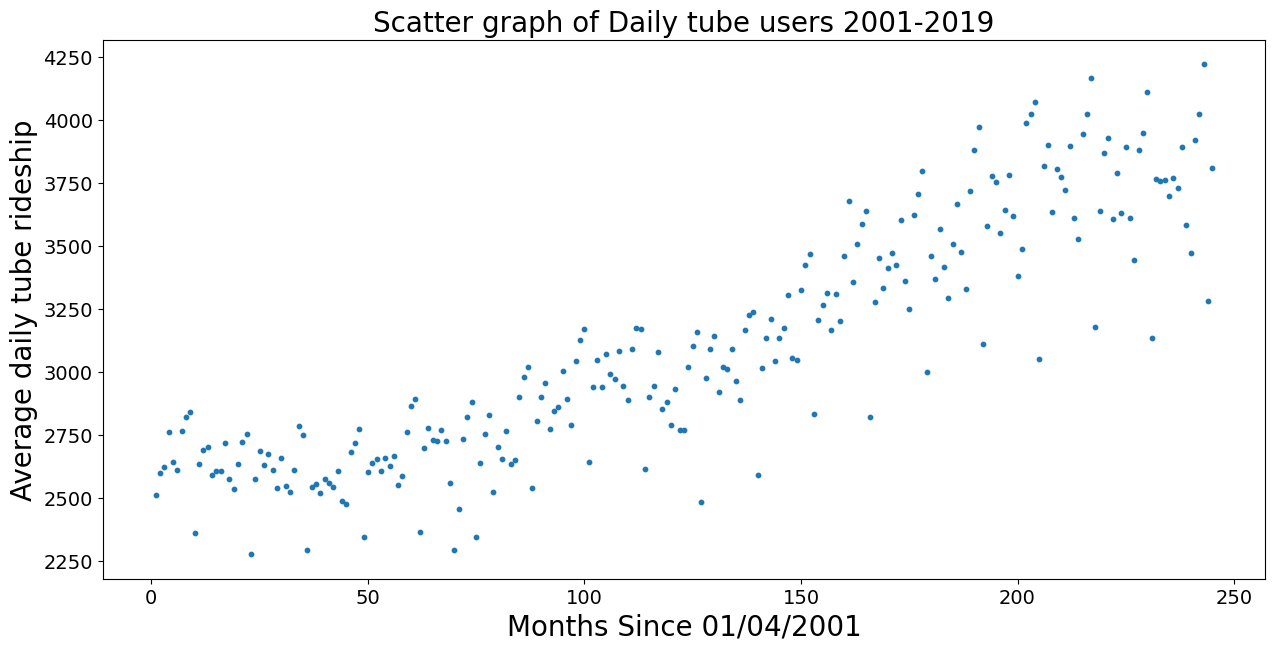

In [74]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [15, 7]
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

plt.scatter(xvals, yvals, s=10)   # s can be used to adjust the size of the dots
plt.xlabel('Months Since 01/04/2001')
plt.ylabel('Average daily tube rideship')
plt.title('Scatter graph of Daily tube users 2001-2019')

plt.show()




## 3b) Fit a linear model $f(x) = \beta_0 + \beta_1 x$ to the data

- Print the values of the regression coefficients $\beta_0, \beta_1$ determined using least-squares. 
- Plot the fitted model and the scatterplot on the same plot.
- Compute and print the **MSE** and the $R^2$ coefficient for the fitted model.

All numerical outputs should be displayed to three decimal places.

beta_0 =  2367.382  	 beta_1 =  5.939


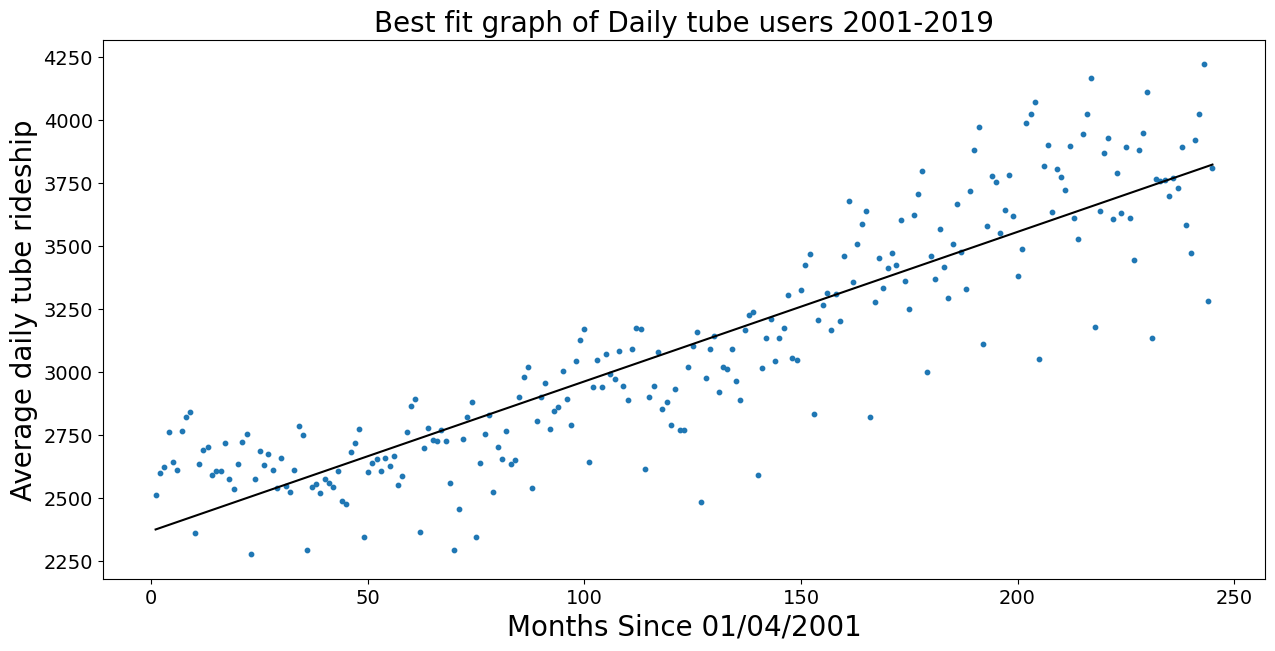

SSE_0 =  54329477.0  	 SSE_1 =  11104290.801
MSE_1 =  45323.636  	 R^2 =  0.796


In [75]:
#From Exercise 1
def polyreg(data_matrix, k):

    N = np.shape(data_matrix)[0]

    if k<N:
        order=k
    else:
        order=N-1

    x_data = data_matrix[:,0]  
    y_data = data_matrix[:,1]

  
    X = np.column_stack([x_data**i for i in range (0,order+1)])
    XT= X.T 
    
    betas = np.linalg.inv(XT.dot(X)).dot(XT.dot(y_data)) 
    fit = X.dot(betas)
    resid = y_data - fit


    #appending additional zeros
    betas=np.append(betas,[0 for i in range(order,k)])
    # The function should return the the coefficient vector beta, the fit, and the vector of residuals  
    return(betas,fit,resid)


data_matrix = np.column_stack([xvals,yvals])
betas,fit,resid=polyreg(data_matrix,1)

print('beta_0 = ', np.round(betas[0], 3), ' \t beta_1 = ', np.round(betas[1], 3))


plt.scatter(xvals, yvals, s=10)   # s can be used to adjust the size of the dots
plt.plot(xvals, fit, color = 'black')   # s can be used to adjust the size of the dots
plt.xlabel('Months Since 01/04/2001')
plt.ylabel('Average daily tube rideship')
plt.title('Best fit graph of Daily tube users 2001-2019')

plt.show()

fit_0 = np.full_like(yvals, np.mean(yvals)) 
SSE_0 = np.linalg.norm(yvals - fit_0)**2
SSE_1 = np.linalg.norm(resid)**2
MSE_1 = SSE_1/np.size(yvals)
R2 = 1 - SSE_1/SSE_0

print('SSE_0 = ', np.round(SSE_0, 3), ' \t SSE_1 = ', np.round(SSE_1, 3))
print('MSE_1 = ', np.round(MSE_1, 3), ' \t R^2 = ', np.round(R2, 3))

## 3c)  Plotting the residuals

- Plot the residuals on a scatterplot
- Also plot the residuals over a short duration and comment on whether you can discern any periodic components.

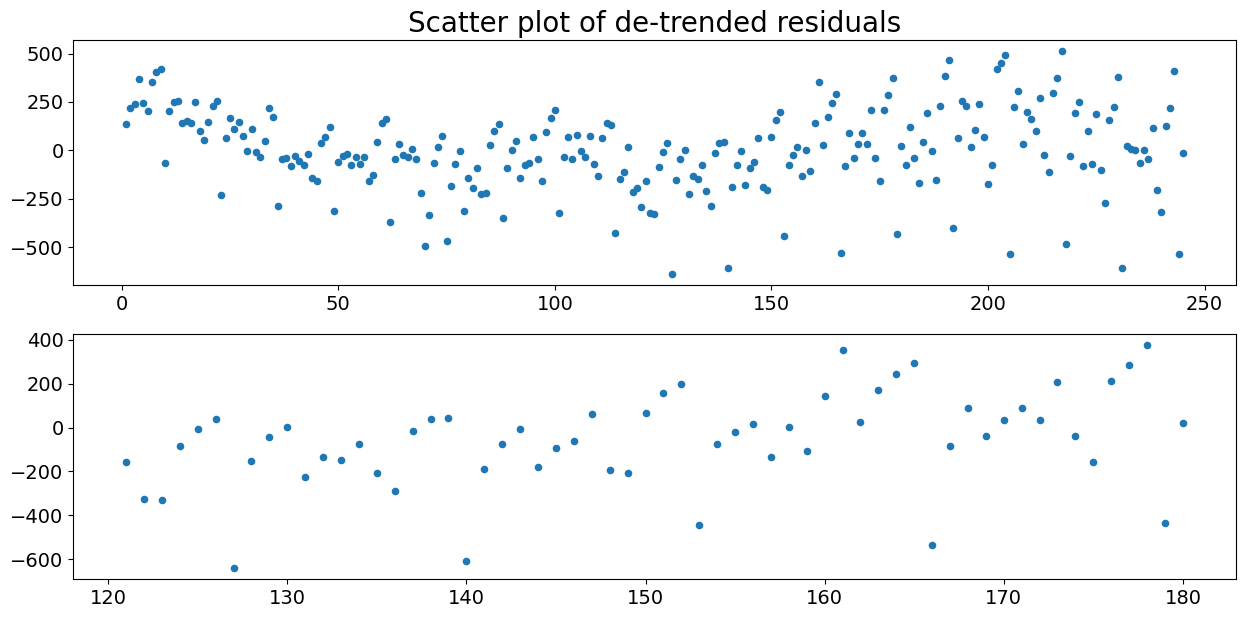

In [76]:
plt.subplot(211)
plt.scatter(xvals, resid, s=20)

plt.title('Scatter plot of de-trended residuals')
# Zoom in to a few values
plt.subplot(212)
plt.scatter(xvals[120:180], resid[120:180], s=20)

plt.show()

There appears to be a consistent drop (single data point) every 12 month period or so, and the overall shape seems to repeat every year. This is an expected pattern.

### 3d) Periodogram

- Compute and plot the peridogram of the residuals. (Recall that the periodogram is the squared-magnitude of the DFT coefficients.)
- Identify the indices/frequencies for which the periogram value exceeds **50%** of the maximum. 


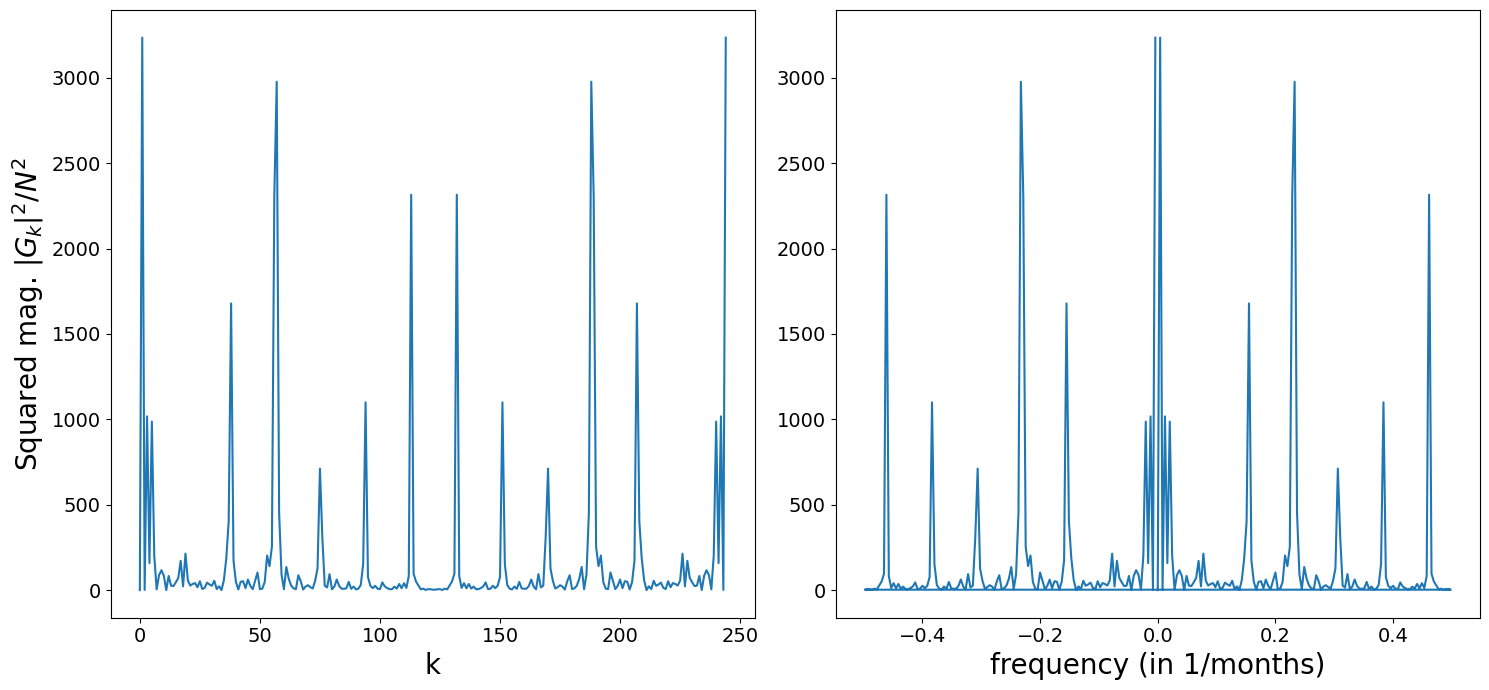

In [77]:
N = np.size(xvals)
T = 1  # period between each data point is 1 month

# Note that T is in months

# Compute the squared magnitudes of the DFT coefficients -- this is known as the "periodogram"
pgram = np.abs(np.fft.fft(resid, N)/N)**2 #We normalize by N, but this is optional
indices = np.linspace(0, (N-1), num = N)
freqs_in_hz = np.fft.fftfreq(N)/T
freqs_in_rads = freqs_in_hz*2*math.pi

plt.subplot(121)
plt.plot(indices, pgram)
plt.xlabel('k')
plt.ylabel('Squared mag. $|G_k|^2/N^2$')
plt.subplot(122)
plt.plot(freqs_in_hz, pgram)
plt.xlabel('frequency (in 1/months)')  # Since units of T is months
plt.savefig('DFT_CO2.pdf', bbox_inches = 'tight')
plt.tight_layout()




In [78]:
top_inds = indices[(pgram > 0.5*np.max(pgram))]
top_freqs_hz = freqs_in_hz[(pgram > 0.5*np.max(pgram))]
print('Top indices:', top_inds, ' Top frequencies in Hz:', top_freqs_hz)

Top indices: [  1.  38.  56.  57. 113. 132. 188. 189. 207. 244.]  Top frequencies in Hz: [ 0.00408163  0.15510204  0.22857143  0.23265306  0.46122449 -0.46122449
 -0.23265306 -0.22857143 -0.15510204 -0.00408163]


## 3e) To the residuals,  fit a model of the form  

$$ \beta_{1s} \sin(\omega_1 x) + \beta_{1c} \cos(\omega_1 x) + \beta_{2s} \sin(\omega_2 x) + \beta_{2c} \cos(\omega_2 x) + \ldots + \beta_{Ks} \sin(\omega_K x) + \beta_{Kc} \cos(\omega_K x).$$

The frequencies $\omega_1, \ldots, \omega_K$ in the model are those corresponding to the indices identified in Part 2c. (Hint: Each of the sines and cosines will correspond to one column in your X-matrix.)

- Print the values of the regression coefficients obtained using least-squares. 

All numerical outputs should be displayed to three decimal places.

In [79]:
def sinusoid_fit(resid_matrix,freqs_in_hz):

    freqs_in_rads = 2*np.pi*freqs_in_hz
    x_data = resid_matrix[:,0]  
    resid_data = resid_matrix[:,1]

    XT = np.vstack([np.vstack([np.sin(w*x_data), np.cos(w*x_data)]) for w in freqs_in_rads])
    X = np.transpose(XT)

    beta_sc = np.linalg.inv(XT.dot(X)).dot(XT).dot(resid_data) # Calculating the least-squares coefficients
    #print('The coefficients beta_s, beta_c are:', beta_sc)
    fit_sc = X.dot(beta_sc)
    resid_sc = resid_data - fit_sc

    return(beta_sc,fit_sc,resid_sc)


resid_matrix = np.column_stack([xvals,resid])
freqs_in_hz = np.array([f for f in top_freqs_hz if f>0])
beta_sc,fit_sc,resid_sc = sinusoid_fit(resid_matrix,freqs_in_hz)

for i in range(0,len(beta_sc),2):
    print('freq_'+ str((i//2)+1) +' = ', np.round(freqs_in_hz[i//2],3) ,' 1/month \t beta_'+ str((i//2)+1) +'s = ', np.round(beta_sc[i], 3), 
          ' \t beta_'+ str((i//2)+1) +'c = ', np.round(beta_sc[i+1], 3))



freq_1 =  0.004  1/month 	 beta_1s =  -51.253  	 beta_1c =  101.556
freq_2 =  0.155  1/month 	 beta_2s =  61.628  	 beta_2c =  -54.006
freq_3 =  0.229  1/month 	 beta_3s =  -15.581  	 beta_3c =  -94.797
freq_4 =  0.233  1/month 	 beta_4s =  81.659  	 beta_4c =  72.381
freq_5 =  0.461  1/month 	 beta_5s =  32.472  	 beta_5c =  90.589


### 3f) The combined fit
- Plot the combined fit together with a scatterplot of the data
- Compute and print the final **MSE** and $R^2$ coefficient. Comment on the improvement over the linear fit.

The combined fit, which corresponds to the full model

$$
f(x) = \beta_0 + \beta_1 x + \beta_{s1} \sin(\omega_1 x) + \beta_{c1} \cos(\omega_1 x) + \ldots + \beta_{sk} \sin(\omega_k x) + \beta_{ck} \cos(\omega_k x),
$$

can be obtained by adding the fits in parts 2b) and 2e).

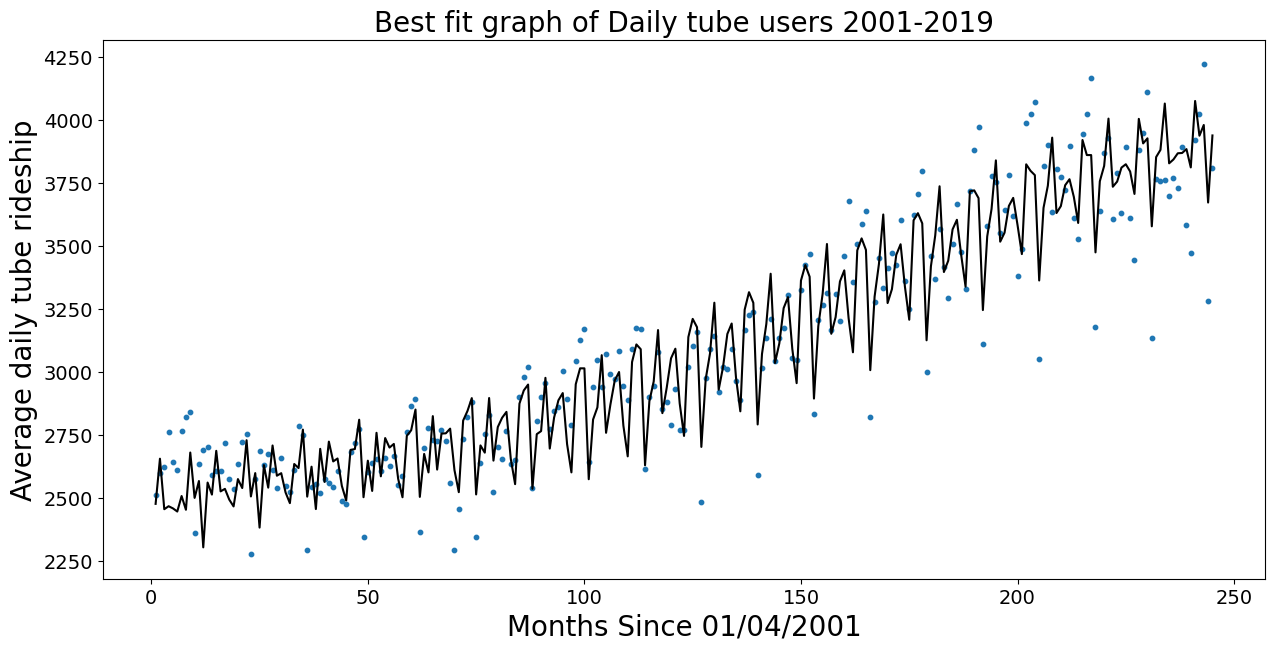

SSE_0 =  54329477.0  	 SSE_sc =  4972887.791
MSE_sc =  45323.636  	 R^2 =  0.908


In [80]:
total_fit = fit + fit_sc

plt.scatter(xvals, yvals, s=10)   # s can be used to adjust the size of the dots
plt.plot(xvals, total_fit, color = 'black')   # s can be used to adjust the size of the dots
plt.xlabel('Months Since 01/04/2001')
plt.ylabel('Average daily tube rideship')
plt.title('Best fit graph of Daily tube users 2001-2019')

plt.show()

SSE_final = np.linalg.norm(resid_sc)**2
MSE_final = SSE_final/np.size(yvals)
R2_final = 1 - SSE_final/SSE_0

print('SSE_0 = ', np.round(SSE_0, 3), ' \t SSE_sc = ', np.round(SSE_final, 3))
print('MSE_sc = ', np.round(MSE_1, 3), ' \t R^2 = ', np.round(R2_final, 3))

A significant improvment in goodness of fit: from R^2 = 0.796 in the linear approximation, to R^2 = 0.908 with in sinusoidal components. The overall shape of the plotted curve also fits the data a lot better visually than the initial linear approximation (which only had a general upwards trend prediction). The sinusoidal inclusion alows the model to predict seasonal variation. Further testing, with greater order polynomial trend and more sinusoidal components, displays a better goodness of fit - however, this increases the complexity of the model.